IMPORT PACKAGES
**bold text**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')
import statsmodels.api as sm

**LOAD DATASET**

In [ ]:
#Load datasets for two subjects, Math and Portuguese
mat = pd.read_csv("student-mat.csv", sep=',')
por = pd.read_csv("student-por.csv", sep=',')

In [ ]:
# merge datasets
df = pd.concat([mat,por])

**DATA PREPARATION**

In [ ]:
# rename column labels
df.columns = ['school','sex','age','address','family_size','parents_status','mother_education','father_education',
           'mother_job','father_job','reason','guardian','commute_time','study_time','failures','school_support',
          'family_support','paid_classes','activities','nursery','desire_higher_edu','internet','romantic','family_quality',
          'free_time','go_out','weekday_alcohol_usage','weekend_alcohol_usage','health','absences','period1_score','period2_score','final_score']

In [ ]:
# convert final_score to categorical variable # Good:15~20 Fair:10~14 Poor:0~9
df['final_grade'] = 'na'
df.loc[(df.final_score >= 15) & (df.final_score <= 20), 'final_grade'] = 'good'
df.loc[(df.final_score >= 10) & (df.final_score <= 14), 'final_grade'] = 'fair'
df.loc[(df.final_score >= 0) & (df.final_score <= 9), 'final_grade'] = 'poor'
df.head(5)

,school,sex,age,address,family_size,parents_status,mother_education,father_education,mother_job,father_job,...,free_time,go_out,weekday_alcohol_usage,weekend_alcohol_usage,health,absences,period1_score,period2_score,final_score,final_grade
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,poor
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,poor
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,fair
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,good
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,fair


In [ ]:
# look for missing values
df.isnull().any()

,0
school,False
sex,False
age,False
address,False
family_size,False
parents_status,False
mother_education,False
father_education,False
mother_job,False
father_job,False


**FINAL GRADE DISTRIBUTION**

<ipython-input-8-f6521ff0b2d7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df.final_grade, order=["poor","fair","good"], palette='Set1')


Text(0, 0.5, 'Number of Student')

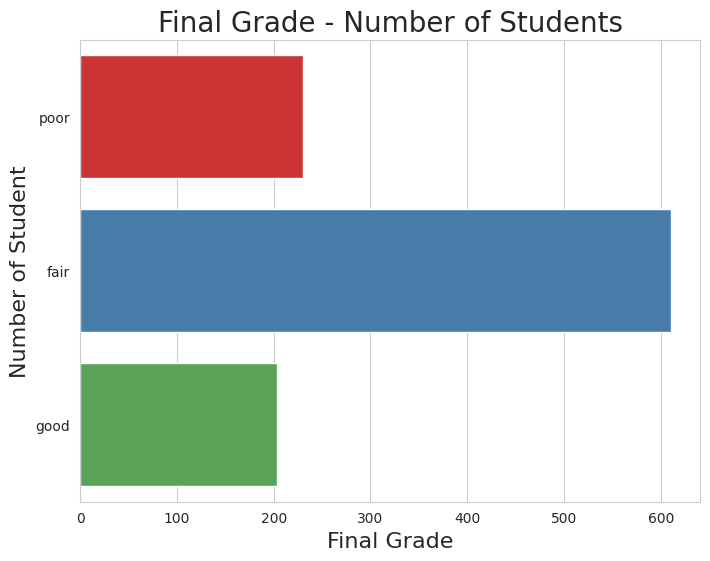

In [ ]:
# Final Grade Countplot
plt.figure(figsize=(8,6))
sns.countplot(df.final_grade, order=["poor","fair","good"], palette='Set1')
plt.title('Final Grade - Number of Students',fontsize=20)
plt.xlabel('Final Grade', fontsize=16)
plt.ylabel('Number of Student', fontsize=16)

**PREPARE DATASET FOR MODELLING**

In [ ]:
# create dataframe dfd for classification
dfd = df.copy()
dfd = dfd.drop([ 'final_score'], axis=1)

In [ ]:
# label encode final_grade
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
dfd.final_grade = le.fit_transform(dfd.final_grade)

In [ ]:
# Dataset train_test_split
from sklearn.model_selection import train_test_split

X = dfd.drop('final_grade', axis=1)
y = dfd.final_grade
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
# get dummy varibles
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [ ]:
# see total number of features
len(list(X_train))

58

**RANDOM FOREST CLASSIFICATION**

In [ ]:
# find a good # of estimators
from sklearn.ensemble import RandomForestClassifier

ne=[]
for i in range(1,58):
    forest = RandomForestClassifier()
    f = forest.fit(X_train, y_train)
    fs = f.score(X_test, y_test)
    ne.append(fs)
ne = pd.Series(ne)
ne.where(ne==ne.max()).dropna()

,0
13,0.888535


In [ ]:
# find a good # of min_samples_leaf
from sklearn.ensemble import RandomForestClassifier

ne=[]
for i in range(1,58):
    forest = RandomForestClassifier(n_estimators=13, min_samples_leaf=i)
    f = forest.fit(X_train, y_train)
    fs = f.score(X_test, y_test)
    ne.append(fs)
ne = pd.Series(ne)
ne.where(ne==ne.max()).dropna()

,0
2,0.88535


In [ ]:
from joblib import dump, load

forest = RandomForestClassifier(n_estimators=13, min_samples_leaf=2)
f = forest.fit(X_train, y_train)

# Save the model
dump(f, 'random_forest_model.joblib')

# Print scores
print("Random Forest Model Score:", f.score(X_train, y_train), ",",
      "Cross Validation Score:", f.score(X_test, y_test))


Random Forest Model Score: 0.9671232876712329 , Cross Validation Score: 0.8439490445859873


In [ ]:
# Example of new data
new_data = pd.DataFrame({
    'age': [17],
    'mother_education': [4],
    'father_education': [4],
    'study_time': [4],
    'desire_higher_edu': ['yes'],
    'absences': [5],
    'period1_score': [18],
    'period2_score': [19]
})

# Match the structure of the training data
new_data = pd.get_dummies(new_data)

# Align with the training data columns
new_data = new_data.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
from joblib import load

# Load the saved Random Forest model
forest = load('random_forest_model.joblib')

In [ ]:
# Predict the class
predicted_class = forest.predict(new_data)

# If you want probabilities for each class
predicted_probabilities = forest.predict_proba(new_data)

# Decode the predicted class back to the original labels
predicted_class_label = le.inverse_transform(predicted_class)

print("Predicted Class:", predicted_class)
print("Predicted Class Label:", predicted_class_label)
print("Predicted Probabilities:", predicted_probabilities)

Predicted Class: [1]
Predicted Class Label: ['good']
Predicted Probabilities: [[0.23796296 0.7037037  0.05833333]]
